# 94 - Generative Adversarial Networks

**Section:** GANs | **Prereqs:** `Autoencoders/CodeChallenge_LatentSpace.ipynb` | **Next:** `GANs/Linear_GANs_FMNIST.ipynb`

Two networks trained against each other:

- **Generator** - noise vector (64 numbers) in, image (784 pixels) out. Never
  sees a real image.
- **Discriminator** - image in, one probability out: real or fake.

The discriminator learns to catch fakes; the generator learns to fool it. Each
one's improvement makes the other's job harder, and the generator improves without
ever being shown a target image - only the discriminator's opinion.

**Why the loss curves look wrong.** In every other notebook in this course a
falling loss means progress. Here it does not: the two losses are in opposition,
and a loss that goes to zero means one network *won*, which is failure. What you
want is sustained oscillation, and a discriminator whose output on both real and
fake images sits near 0.5 - it can no longer tell.

**GANs vs autoencoders.** An autoencoder compresses a *given* image and rebuilds
it, so it can only reproduce what it was shown, and MSE makes the result blurry.
A GAN starts from noise and produces genuinely new images, and because its loss
is another network's judgement rather than pixel distance, the output is sharp.

**Three practical details in the code**
- Data scaled to [-1,1] to match the generator's `Tanh` output.
- No DataLoader - batches are drawn by random index. Fine here, since batch
  composition matters less than in supervised training.
- Two separate optimizers. Never one over both parameter sets - they are
  optimising opposite objectives.

**GANs are famously unstable.** Mode collapse (the generator finds one image that
fools the discriminator and emits only that), oscillation, and outright divergence
are all normal. The architecture rules in the CNN GAN notebooks exist precisely
because of this.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchsummary

import sys

# GAN Architecture Overview

## Generator Network
| Layer | Units | Activation |
|-------|-------|------------|
| Input | 64 | - |
| Layer 1 | 256 | Leaky ReLU |
| Layer 2 | 256 | Leaky ReLU |
| Output | 784 | Tanh |

## Discriminator Network
| Layer | Units | Activation |
|-------|-------|------------|
| Input | 784 | - |
| Layer 1 | 256 | Leaky ReLU |
| Layer 2 | 256 | Leaky ReLU |
| Output | 1 | Sigmoid |

## Objective Function

$$\min_G \max_D V(D,G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1-D(G(z)))]$$

## Generator Formula

$$G(z) = \tanh(W_g \cdot \text{ReLU}(W_h \cdot \text{ReLU}(W_i \cdot z + b_i) + b_h) + b_g)$$

## Discriminator Formula

$$D(x) = \sigma(W_d \cdot \text{ReLU}(W_{d2} \cdot \text{ReLU}(W_{d1} \cdot x + b_{d1}) + b_{d2}) + b_d)$$

---

## Key Notes
- **Leaky ReLU**: $f(x) = x$ if $x > 0$, else $0.01x$
- **Tanh**: Output range $[-1, 1]$
- **Sigmoid**: Output range $[0, 1]$
- **Typical Use**: Image generation (e.g., MNIST 28×28)

In [48]:
data = torchvision.datasets.MNIST(root='/', download=True, train=True)
data

Dataset MNIST
    Number of datapoints: 60000
    Root location: /
    Split: Train

In [49]:
# MNIST as raw uint8 pixels.
data = data.data
data.shape, type(data)

(torch.Size([60000, 28, 28]), torch.Tensor)

In [50]:
# Flattened to 784 - this is the linear (fully connected) GAN.
data = data.reshape(data.shape[0],784)
data.shape

torch.Size([60000, 784])

In [51]:
# Scale to [-1,1], NOT [0,1]. This matters: the generator ends in Tanh, whose
# range is exactly [-1,1]. Mismatched ranges here mean the generator can never
# produce values the discriminator sees in real data, and it is an easy way to
# make a GAN fail for reasons that look like instability.
datanorm = data / torch.max(data) # -> [0,1]
datanorm = 2*datanorm - 1 # -> [-1,1] since 2*0 - 1 = -1, and 1*2 - 1 = 1

datanorm.max() , datanorm.min() # We do this because this is recommended

(tensor(1.), tensor(-1.))

In [52]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [53]:
datanorm = datanorm.float().to(device)

In [54]:
type(datanorm) , datanorm.dtype

(torch.Tensor, torch.float32)

In [55]:
# Batch size 100. No DataLoader - batches are drawn by random index below.
# No data loaders in GANs

batchsize = 100

# Now we create the generator and discriminator class

In [56]:
# The DISCRIMINATOR: 784 -> 256 -> 256 -> 1, sigmoid out.
# An ordinary binary classifier. Its output is P(this image is real).
class discriminator_net(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.fc1 = nn.Linear(28*28,256)
    self.fc2 = nn.Linear(256,256)
    self.out = nn.Linear(256,1)

  def forward(self,x):

    x = F.leaky_relu(self.fc1(x),inplace=True)
    x = F.leaky_relu(self.fc2(x), inplace=True)

    return torch.sigmoid(self.out(x))


dnet = discriminator_net().to(device)

In [57]:
torchsummary.summary(dnet, (784,),batch_size=100)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [100, 256]         200,960
            Linear-2                 [100, 256]          65,792
            Linear-3                   [100, 1]             257
Total params: 267,009
Trainable params: 267,009
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.30
Forward/backward pass size (MB): 0.39
Params size (MB): 1.02
Estimated Total Size (MB): 1.71
----------------------------------------------------------------


In [58]:
# The GENERATOR: 64 -> 256 -> 256 -> 784, Tanh out.
# It maps a point in a 64-dimensional latent space to an image. The mapping is
# what training shapes; the input is pure noise.
# The generator's architecture MIRRORS the discriminator's - a common starting
# point, so neither can overpower the other early on.
class generator(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.fc1 = nn.Linear(64,256)
    self.fc2 = nn.Linear(256,256)
    self.out = nn.Linear(256,784)

  def forward(self,x):

    x = F.leaky_relu(self.fc1(x),inplace=True)
    x = F.leaky_relu(self.fc2(x), inplace=True)

    return F.tanh(self.out(x))

gnet = generator().to(device)

In [59]:
torchsummary.summary(gnet, (64,),batch_size=100)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [100, 256]          16,640
            Linear-2                 [100, 256]          65,792
            Linear-3                 [100, 784]         201,488
Total params: 283,920
Trainable params: 283,920
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 0.99
Params size (MB): 1.08
Estimated Total Size (MB): 2.10
----------------------------------------------------------------


In [60]:
# Generating from random noise before any training.
# Testing with real inputs
test_output = gnet(torch.randn((10,64)).to(device))

test_output.shape

torch.Size([10, 784])

In [61]:
test_output[0].shape

torch.Size([784])

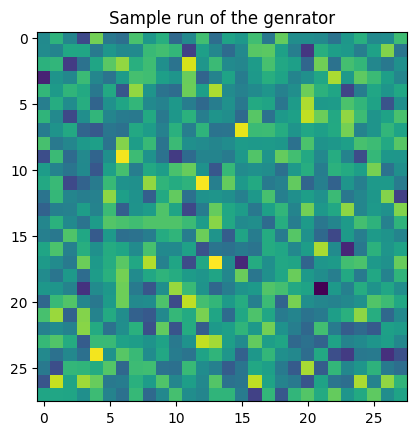

In [62]:
# Untrained output: noise. Everything the generator will ever know comes from
# the discriminator's gradients.
plt.imshow(test_output[0].detach().squeeze().view(28,28).cpu())
plt.title("Sample run of the genrator");

# Now we train the models

In [63]:
# Two separate optimizers, one per network. Never a single optimizer over both -
# they are minimising opposite objectives, and one optimizer would try to do both
# at once.
# Equal learning rates keep the two in balance; if one consistently overpowers
# the other, this is the first knob to turn.
lossfunc = nn.BCELoss() # No inbuilt sigmoid

epochs = 50000

# We need 2 differnet optimizers for gnet and dnet (We are training them seperatly)

d_optimizer = torch.optim.Adam(dnet.parameters(), lr=0.0003) # Genreally the idea is small learning rate, with lots of epochs.. Slow but long training
g_optimizer = torch.optim.Adam(gnet.parameters(), lr=0.0003)

In [64]:
# randidx = torch.randint(datanorm.shape[0],(batchsize,)) We take randoem 100 indeces from this, and datanorm.shape[0] , is the upper bound
# randidx.shape

In [65]:
# THE GAN TRAINING LOOP. Two models, two optimizers, one alternating step:
#
# 1. DISCRIMINATOR: show it real images labelled 1 and fake images labelled 0,
#    and minimise BCE on both. It learns to tell them apart.
# 2. GENERATOR: make fresh fakes, run them through the discriminator, and
#    minimise BCE against label 1 - i.e. train the generator to make the
#    discriminator say 'real'.
#
# The label flip in step 2 is the whole trick: the generator has no direct
# target image, only the discriminator's opinion, so 'be more convincing' is
# expressed as 'make D output 1'.
#
# Fakes are REGENERATED between the two steps. Reusing the step-1 fakes would
# backpropagate through a stale graph, and torch would raise.
#
# What to watch: d_loss and g_loss should stay in tension. If d_loss collapses
# to 0 the discriminator won and the generator gets no useful gradient; if
# g_loss collapses the generator found a blind spot. Neither loss going to zero
# is success - equilibrium is.
losses = torch.zeros((epochs, 2))
discDes = torch.zeros((epochs,2)) # Discriminator Decisions

for epoch in range(epochs):
  # Making minibatches

  randidx = torch.randint(datanorm.shape[0],(batchsize,))
  real_images = datanorm[randidx,:].to(device)
  fake_images = gnet(torch.randn((batchsize,64)).to(device))

  # Add Labels
  real_labels = torch.ones((batchsize,1)).to(device)
  fake_labels = torch.zeros((batchsize,1)).to(device)


  #-------------------Training the Discriminator-------------------#

  # Forward pass and loss for real images. In this step the model is trying to minimize the loss and trying to learn to classify all real images as 1. As we are calculating loss with all real data to be 1. (preds,(bunch of 1s))
  preds_real = dnet(real_images)
  d_loss_real = lossfunc(preds_real,real_labels) # Remember all real_labels are 1s.


  # Forward pass and loss for fake images. In this step the model is trying to minimize the loss and trying to learn to classify all fake images as 0.
  preds_fake = dnet(fake_images)
  d_loss_fake = lossfunc(preds_fake,fake_labels) # Remember all fake_labels are 0s.

  d_loss = d_loss_real + d_loss_fake # We can bias the loss term in some cases, if we want the model to strongly reject fake data at the expense of real data in some cases.
  losses[epoch,0] = d_loss.item()
  discDes[epoch,0] = torch.mean((preds_real > 0.5).float()).detach()

  d_optimizer.zero_grad()
  d_loss.backward()
  d_optimizer.step()


  #-------------------Training the Generator-------------------#

  # We create more noise to start with.

  fake_images = gnet(torch.randn((batchsize,64)).to(device))
  preds_fake = dnet(fake_images) # We get the discrimator to judge these images.

  # Computing loss for gnet
  g_loss = lossfunc(preds_fake, real_labels) # In this step now the generator will learn to create images which will be classified by dnet as 1. Since we are calcuating the error comapared to the all 1 inputs.
  losses[epoch,1] = g_loss.item()
  discDes[epoch,1] = torch.mean((preds_fake > 0.5).float()).detach()

  g_optimizer.zero_grad()
  g_loss.backward()
  g_optimizer.step()


  if epoch % 500 == 0 or epoch == epochs-1 :
    msg = f'Finished training epoch {epoch}/{epochs}'

    sys.stdout.write('\r' + msg)


Finished training epoch 49999/50000

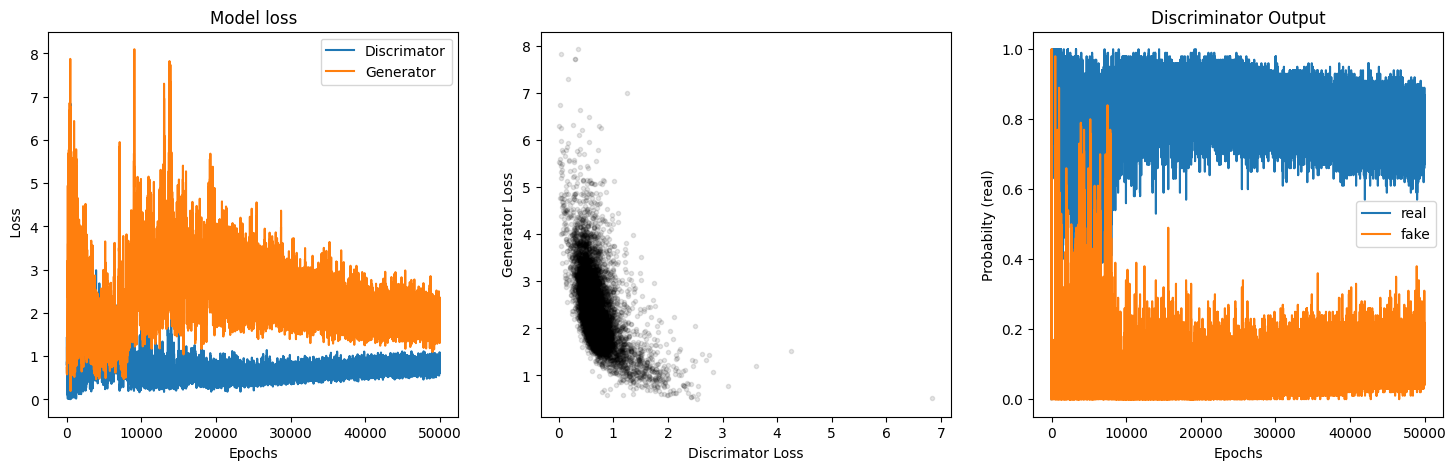

In [66]:
# The three GAN diagnostics:
# LEFT   - both losses over time. Look for sustained oscillation, not
#          convergence. A GAN that 'converges' has usually collapsed.
# MIDDLE - discriminator loss against generator loss. A diagonal cloud means the
#          two are trading blows; a point in one corner means one has won.
# RIGHT  - the discriminator's decisions on real and fake. At equilibrium both
#          approach 0.5: it can no longer tell them apart. That is the target,
#          and it is the closest thing a GAN has to an accuracy metric.
fig,ax = plt.subplots(1,3, figsize=(18,5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel(' Loss')
ax[0].set_title('Model loss')
ax[0].legend(['Discrimator', 'Generator'])
#ax[0].set_xlim([3000,4000])

ax[1].plot(losses [::5,0], losses [::5,1], 'k.',alpha=.1)
ax[1].set_xlabel('Discrimator Loss')
ax[1].set_ylabel('Generator Loss')

ax[2].plot(discDes)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Probabilty (real)')
ax[2].set_title('Discriminator Output')
ax[2].legend(['real', 'fake']);


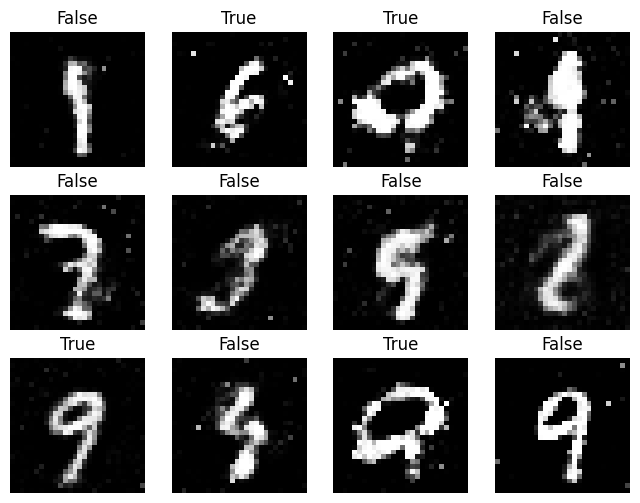

In [67]:
# Twelve generated digits from fresh noise, titled with the discriminator's
# verdict.
# Read them for MODE COLLAPSE: if most of the twelve look alike, the generator
# found one convincing output and stopped exploring. Variety across the grid is
# as important as quality within it.
# Now we generate fake data, we start with pure random noise.

gnet.eval()
fake_data = gnet(torch.randn(12,64).to(device)).cpu()
fake_pred = dnet(fake_data.to(device))

# and visualize...
fig, axs = plt.subplots(3,4, figsize=(8,6))

for i, ax in enumerate(axs.flatten()):
  ax.imshow (fake_data[i,:,].detach().view(28,28), cmap='gray')
  ax.set_title((fake_pred[i] > 0.5).item())
  ax.axis('off')

plt.show()

## GAN Training Overview

- **Discriminator training:** feed it both real and fake images.
  - Real images → target label **1**
  - Fake images → target label **0**
  - Goal: learn to distinguish real from fake.

- **Generator training:** feed only fake images.
  - Fake images → target label **1**
  - Goal: fool the discriminator into thinking fakes are real.

## What `discDes` Tracks

`discDes` stores the discriminator's binary decisions per epoch:

- `discDes[:, 0]` → % of **real** images classified as real
- `discDes[:, 1]` → % of **fake** images classified as real

At convergence, both should approach **0.5**, meaning the discriminator cannot tell real and fake apart.

> **Threshold note:** use `> 0.5` if the discriminator outputs probabilities (sigmoid + `BCELoss`). If using logits with `BCEWithLogitsLoss`, use `> 0` instead.